In [33]:
import os
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import pandas as pd

class SEBMultiExperimentPlotter:
    def __init__(self, base_dir, experiments, ensemble='EN01', region='global', frequency='monthly', 
                 compute_ensemble_mean=False, mask_path=None, save_dir=None, 
                 experiment_labels=None, show_significance=False):
        """
        Parameters:
        - base_dir: Path to processed SEB outputs.
        - experiments: List of experiment names (e.g., ['CTRLEN10', 'DARTEN20']).
        - ensemble: Common ensemble ID (e.g., 'EN01') or None if computing ensemble mean.
        - region: 'global', 'land', or 'ocean'.
        - frequency: 'daily' or 'monthly'.
        - compute_ensemble_mean: If True, load all members in experiment and average.
        - mask_path: (Optional) path to landmask NetCDF.
        - save_dir: (Optional) path to save figures.
        - experiment_labels: (Optional) dict mapping experiment keys to display names.
        - show_significance: (Optional) flag to enable significance testing.
        """
        self.data = {}
        self.region = region
        self.frequency = frequency
        self.ensemble = ensemble
        self.compute_ensemble_mean = compute_ensemble_mean
        self.mask_path = mask_path
        self.save_dir = save_dir
        self.experiment_labels = experiment_labels if experiment_labels else {e: e for e in experiments}
        self.show_significance = show_significance

        for exp in experiments:
            exp_dir = os.path.join(base_dir, exp)
            if compute_ensemble_mean:
                members = sorted([f for f in os.listdir(exp_dir)
                                  if f.endswith(f"_{region}.nc") and frequency in f])
                for f in members:
                    path = os.path.join(exp_dir, f)
                    try:
                        all_members.append(xr.open_dataset(path))
                    except Exception as e:
                        print(f"[WARN] Skipping {f} due to error: {e}")
                if all_members:
                    combined = xr.concat(all_members, dim='ens').mean('ens')
                    self.data[exp] = combined
            else:
                # Support year-month tagged filenames like seb_monthly_EN01_land_2011-12.nc
                print(exp_dir)
                all_files = [
                    f for f in os.listdir(exp_dir)
                    if f.startswith(f"seb_{self.frequency}_{self.ensemble}_{self.region}_") and f.endswith(".nc")
                ] 
                print(all_files)
                filtered = [f for f in all_files if f.startswith(f"seb_{self.frequency}_{self.ensemble}_{self.region}_")]
                if filtered:
                    datasets = [xr.open_dataset(os.path.join(exp_dir, f)) for f in filtered]
                    combined = xr.concat(datasets, dim='time')
                    self.data[exp] = combined
                else:
                    print(f"[WARN] No files found for {exp} with pattern seb_{frequency}_{ensemble}_{region}_YYYY-MM.nc")

    def plot_timeseries_comparison(self, variable='Rn'):
        plt.figure(figsize=(12, 5))
        for exp, ds in self.data.items():
            mean_ts = ds[variable].mean(dim=['lat', 'lon'])
            mean_ts.plot(label=self.experiment_labels.get(exp, exp))
        plt.title(f"{self.region.upper()} | {variable} Time Series")
        plt.ylabel("W/m²")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        if self.save_dir:
            fpath = os.path.join(self.save_dir, f"timeseries_{variable}_{self.region}.png")
            plt.savefig(fpath, dpi=150)
            print(f"[SAVED] {fpath}")
        plt.show()

    def plot_seb_components_timeseries(self, experiment_key):
        """
        Plot time series of LE, SH, and Rn for a selected experiment.
        Assumes daily or sub-daily data over one month.
        """
        if experiment_key not in self.data:
            print(f"[ERROR] Experiment '{experiment_key}' not found.")
            return

        ds = self.data[experiment_key]
        label_map = {"LE": "Latent Heat (LE)", "SH": "Sensible Heat (SH)", "Rn": "Net Radiation (Rn)"}

        # Check all required variables are present
        required_vars = ['LE', 'SH', 'Rn']
        for var in required_vars:
            if var not in ds:
                print(f"[WARN] Missing variable '{var}' in dataset for {experiment_key}")
                return

        # Compute area-mean time series
        ts_dict = {v: ds[v].mean(dim=['lat', 'lon'], skipna=True) for v in required_vars}

        plt.figure(figsize=(10, 5))
        for var in required_vars:
            ts_dict[var].plot(label=label_map[var])

        plt.title(f"{self.experiment_labels.get(experiment_key, experiment_key)} | SEB Components Over Time")
        plt.xlabel("Time")
        plt.ylabel("W/m²")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()

        if self.save_dir:
            fname = f"seb_components_timeseries_{experiment_key}_{self.region}.png"
            fpath = os.path.join(self.save_dir, fname)
            plt.savefig(fpath, dpi=150)
            print(f"[SAVED] {fpath}")

        plt.show()

    
    def plot_monthly_climatology_comparison(self, variable='Rn'):
        plt.figure(figsize=(10, 5))
        clim_data = {}

        for exp, ds in self.data.items():
            ts = ds[variable].mean(dim=['lat', 'lon'])
            clim = ts.groupby("time.month").mean("time")
            clim_data[exp] = clim
            plt.plot(clim['month'], clim, label=self.experiment_labels.get(exp, exp))

        if self.show_significance and len(clim_data) == 2:
            exp1, exp2 = list(clim_data.keys())
            diff = clim_data[exp1] - clim_data[exp2]
            std1 = self.data[exp1][variable].std(dim=['lat', 'lon'])
            std2 = self.data[exp2][variable].std(dim=['lat', 'lon'])
            stderr = np.sqrt(std1**2 + std2**2)
            mask = np.abs(diff) > 2 * stderr
            for m in range(1, 13):
                if mask.sel(month=m):
                    plt.axvline(m, color='gray', linestyle='--', alpha=0.3)

        plt.title(f"{self.region.upper()} | Monthly Climatology of {variable}")
        plt.xlabel("Month")
        plt.ylabel("W/m²")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        if self.save_dir:
            fpath = os.path.join(self.save_dir, f"climatology_{variable}_{self.region}.png")
            plt.savefig(fpath, dpi=150)
            print(f"[SAVED] {fpath}")
        plt.show()

    def plot_bowen_ratio_climatology(self):
        if not any("BowenRatio" in ds for ds in self.data.values()):
            print("[WARN] BowenRatio not available in all datasets.")
            return

        plt.figure(figsize=(10, 5))
        for exp, ds in self.data.items():
            if "BowenRatio" in ds:
                br = ds["BowenRatio"].mean(dim=["lat", "lon"])
                br_clim = br.groupby("time.month").mean("time")
                plt.plot(br_clim['month'], br_clim, label=self.experiment_labels.get(exp, exp))
        plt.title(f"{self.region.upper()} | Monthly Climatology of Bowen Ratio")
        plt.xlabel("Month")
        plt.ylabel("SH / LE")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        if self.save_dir:
            fpath = os.path.join(self.save_dir, f"climatology_BowenRatio_{self.region}.pdf")
            plt.savefig(fpath, dpi=600)
            print(f"[SAVED] {fpath}")
        plt.show()

/compyfs/zhan391/v3_dart_cda_scratch/diag_dart/CTRLEN10
['seb_daily_EN01_land_2011-12.nc', 'seb_daily_EN01_land_2012-01.nc', 'seb_daily_EN01_land_2012-02.nc']
/compyfs/zhan391/v3_dart_cda_scratch/diag_dart/DARTEN20
['seb_daily_EN01_land_2011-12.nc', 'seb_daily_EN01_land_2012-01.nc', 'seb_daily_EN01_land_2012-02.nc']
/compyfs/zhan391/v3_dart_cda_scratch/diag_dart/DARTEN40
['seb_daily_EN01_land_2011-12.nc', 'seb_daily_EN01_land_2012-01.nc', 'seb_daily_EN01_land_2012-02.nc']
[SAVED] /qfs/people/zhan391/e3sm_dart_work/analysis/diagnostic/figures/mean_bias_da/seb_components_timeseries_CTRLEN10_land.png


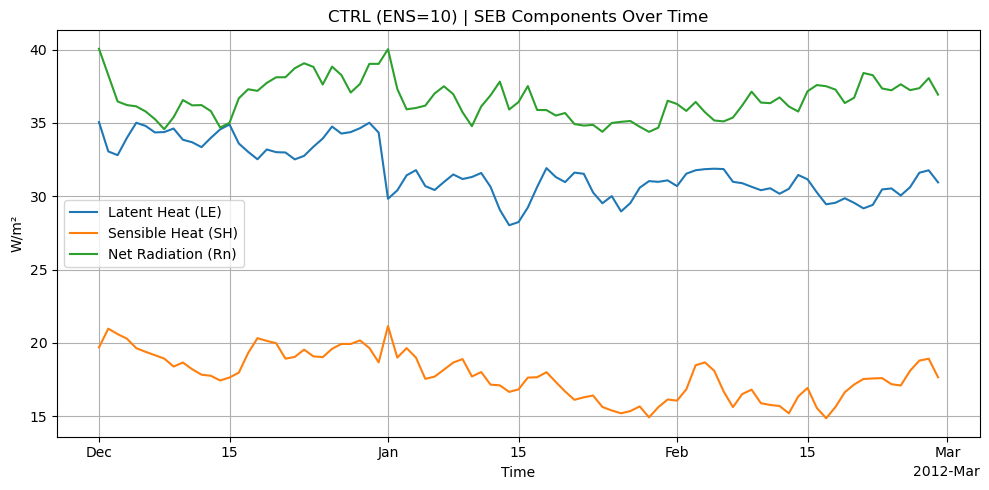

In [34]:
if __name__ == "__main__":
    top_path = "/compyfs/zhan391/v3_dart_cda_scratch"
    out_path = os.path.join(top_path, "diag_dart")
    fig_path = "/qfs/people/zhan391/e3sm_dart_work/analysis/diagnostic/figures/mean_bias_da"
    mask_path = os.path.join(out_path, 'landmask_1x1.nc')
    
    compset = "F20TR"
    resolution = "ne30pg2_r05_IcoswISC30E3r5"
    machine = "compy"
    exp_base = f"{compset}_{resolution}_{machine}"

    model_dict = {
        'CTRLEN10': "CTRL (ENS=10)",
        'DARTEN20': "EAM-DART (ENS=20)",
        'DARTEN40': "EAM-DART (ENS=40)",
    }

    experiments = list(model_dict.keys())
    base_dir = out_path

    os.makedirs(out_path, exist_ok=True)
    os.makedirs(fig_path, exist_ok=True)

    # Initialize the plotter for 'land' region, monthly outputs
    plotter = SEBMultiExperimentPlotter(
        base_dir=base_dir,
        experiments=experiments,
        ensemble='EN01',
        region='land',
        frequency='daily',
        save_dir=fig_path,
        experiment_labels=model_dict,
        show_significance=False  # or True if you want t-test
    )

    # Run plotting
    plotter.plot_seb_components_timeseries("CTRLEN10")

    #plotter.plot_timeseries_comparison(variable='Rn')
    #plotter.plot_timeseries_comparison(variable='LE')
    #plotter.plot_timeseries_comparison(variable='SH')

    #plotter.plot_monthly_climatology_comparison(variable='LE')
    #plotter.plot_bowen_ratio_climatology()